# Day 14 — MultiIndex + Pivot Tables
> **Two sections:** MultiIndex deep dive + E-Commerce Pivot Analysis with Matplotlib

**Author:** Shaurab Kumar Jha  
**Date:** Day 14 of 90  
**Goal:** MNC-ready Python & Gen AI Engineer

## Table of Contents
**Part A — MultiIndex**
1. [What is MultiIndex?](#what)
2. [Creating MultiIndex — from_tuples, from_product, from_arrays](#create)
3. [MultiIndex Series — selection, xs()](#series)
4. [MultiIndex DataFrame (rows)](#rows)
5. [MultiIndex DataFrame (columns)](#cols)
6. [stack() and unstack()](#stack)
7. [swaplevel() and sort_index()](#swap)
8. [transpose (.T)](#transpose)
9. [Wide vs Long Format + melt()](#melt)

**Part B — Pivot Tables (E-Commerce Project)**

10. [pivot_table() — Theory & All Parameters](#theory)
11. [Basic Pivot + margins=True](#basic)
12. [Multi-dimensional Pivots](#multi)
13. [Multiple aggfuncs](#aggfunc)
14. [Visualizations — Heatmap, Bar, Trends](#viz)
15. [Business Insights from Pivot](#insights)
16. [Cheatsheet & Interview Q&A](#cheatsheet)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print(f'Pandas: {pd.__version__}')

Pandas: 2.2.3


---
# PART A — MULTIINDEX

## 1. What is MultiIndex? <a name='what'></a>

### Theory

A **MultiIndex** (also called hierarchical index) allows **multiple levels of labelling** for rows or columns.

```
Normal Index:           MultiIndex:
──────────────          ────────────────────────
'Delhi'  → row 0        ('Delhi', 2022) → row 0
'Mumbai' → row 1        ('Delhi', 2023) → row 1
'Pune'   → row 2        ('Mumbai', 2022) → row 2
                         ('Mumbai', 2023) → row 3

  1 label per row        Tuple of labels per row
  Flat structure         Hierarchical / nested structure
```

**When do you need it?**
- Financial data: `(Stock, Date)`
- Census: `(Country, State, City)`
- Sales: `(Region, Category, Month)`
- Stack/unstack creates MultiIndex automatically
- `groupby()` on multiple columns → MultiIndex result

---
## 2. Creating MultiIndex <a name='create'></a>

In [2]:
# ── from_tuples ───────────────────────────────────────────────
# Manual: list of tuples, each tuple = one row label
tuples = [
    ('Delhi', 2022), ('Delhi', 2023),
    ('Mumbai', 2022), ('Mumbai', 2023),
    ('Chennai', 2022), ('Chennai', 2023),
]
mi_tuples = pd.MultiIndex.from_tuples(tuples, names=['City', 'Year'])
print('from_tuples:')
print(mi_tuples)
print(f'nlevels: {mi_tuples.nlevels}  |  levels: {[l.tolist() for l in mi_tuples.levels]}  |  names: {mi_tuples.names}')

from_tuples:
MultiIndex([(  'Delhi', 2022),
            (  'Delhi', 2023),
            ( 'Mumbai', 2022),
            ( 'Mumbai', 2023),
            ('Chennai', 2022),
            ('Chennai', 2023)],
           names=['City', 'Year'])
nlevels: 2  |  levels: [['Chennai', 'Delhi', 'Mumbai'], [2022, 2023]]  |  names: ['City', 'Year']


In [3]:
# ── from_product ──────────────────────────────────────────────
# Cartesian product: ALL combinations automatically
# 3 cities × 2 years = 6 index entries
cities = ['Delhi', 'Mumbai', 'Chennai']
years  = [2022, 2023]
mi_prod = pd.MultiIndex.from_product([cities, years], names=['City', 'Year'])
print('from_product (3 × 2 = 6 entries):')
print(mi_prod)

from_product (3 × 2 = 6 entries):
MultiIndex([(  'Delhi', 2022),
            (  'Delhi', 2023),
            ( 'Mumbai', 2022),
            ( 'Mumbai', 2023),
            ('Chennai', 2022),
            ('Chennai', 2023)],
           names=['City', 'Year'])


In [4]:
# ── from_arrays ───────────────────────────────────────────────
# Parallel arrays: one array per level
cities_arr = ['Delhi',  'Delhi',  'Mumbai', 'Mumbai']
years_arr  = [2022,     2023,     2022,     2023]
mi_arrays  = pd.MultiIndex.from_arrays([cities_arr, years_arr], names=['City', 'Year'])
print('from_arrays:')
print(mi_arrays)

from_arrays:
MultiIndex([( 'Delhi', 2022),
            ( 'Delhi', 2023),
            ('Mumbai', 2022),
            ('Mumbai', 2023)],
           names=['City', 'Year'])


---
## 3. MultiIndex Series <a name='series'></a>

### xs() — Cross Section
```python
s.xs(key, level='LevelName')
# Select ALL entries where one level = key
# Way more flexible than .loc for hierarchical data
```

In [5]:
pop_data = [32.1, 33.8, 20.7, 21.6, 11.2, 11.9]
pop = pd.Series(pop_data, index=mi_tuples, name='Population_M')
pop = pop.sort_index()   # always sort MultiIndex before slicing!
print('MultiIndex Series:')
print(pop)

MultiIndex Series:
City     Year
Chennai  2022    11.2
         2023    11.9
Delhi    2022    32.1
         2023    33.8
Mumbai   2022    20.7
         2023    21.6
Name: Population_M, dtype: float64


In [6]:
print("pop['Delhi'] — all Delhi entries:")
print(pop['Delhi'])
print()
print("pop['Delhi', 2023] — specific:")
print(pop['Delhi', 2023])

pop['Delhi'] — all Delhi entries:
Year
2022    32.1
2023    33.8
Name: Population_M, dtype: float64

pop['Delhi', 2023] — specific:
33.8


In [7]:
# xs() — cross-section: select by one level's value
print("pop.xs(2022, level='Year') — all cities for 2022:")
print(pop.xs(2022, level='Year'))
print()
print("pop.xs('Mumbai', level='City'):")
print(pop.xs('Mumbai', level='City'))

pop.xs(2022, level='Year') — all cities for 2022:
City
Chennai    11.2
Delhi      32.1
Mumbai     20.7
Name: Population_M, dtype: float64

pop.xs('Mumbai', level='City'):
Year
2022    20.7
2023    21.6
Name: Population_M, dtype: float64


---
## 4. MultiIndex DataFrame — Row Index <a name='rows'></a>

In [8]:
cities_full = ['Delhi', 'Mumbai', 'Chennai', 'Kolkata']
years_full  = [2021, 2022, 2023]
mi_full     = pd.MultiIndex.from_product([cities_full, years_full], names=['City', 'Year'])

df_city = pd.DataFrame({
    'Population_M': np.round(np.random.uniform(5, 35, len(mi_full)), 1),
    'GDP_Billion':  np.round(np.random.uniform(50, 500, len(mi_full)), 1),
    'Unemployment': np.round(np.random.uniform(3, 12, len(mi_full)), 2),
}, index=mi_full)

print(f'Shape: {df_city.shape}  |  Index levels: {df_city.index.nlevels}')
df_city

Shape: (12, 3)  |  Index levels: 2


Population_M  GDP_Billion  Unemployment
City    Year                                         
Delhi   2021          16.2        424.6          7.10
        2022          33.5        145.6         10.07
        2023          27.0        131.8          4.80
Mumbai  2021          23.0        132.5          7.63
        2022           9.7        186.9          8.33
        2023           9.7        286.1          3.42
Chennai 2021           6.7        244.4          8.47
        2022          31.0        181.1          4.53
        2023          23.0        325.3          3.59
Kolkata 2021          26.2        112.8         11.54
        2022           5.6        181.5         11.69
        2023          34.1        214.9         10.28

In [9]:
# Selection patterns
print('df_city.loc["Delhi"] — all Delhi rows:')
display(df_city.loc['Delhi'])

print('\ndf_city.loc[("Delhi", 2022)] — exact row:')
print(df_city.loc[('Delhi', 2022)])

df_city.loc["Delhi"] — all Delhi rows:


,Population_M,GDP_Billion,Unemployment
Year,,,
2021,16.2,424.6,7.10
2022,33.5,145.6,10.07
2023,27.0,131.8,4.80



df_city.loc[("Delhi", 2022)] — exact row:
Population_M     33.50
GDP_Billion     145.60
Unemployment     10.07
Name: (Delhi, 2022), dtype: float64


In [10]:
# xs() on DataFrame
print('xs(2022, level="Year") — all cities for 2022:')
display(df_city.xs(2022, level='Year'))

print('\nxs("Chennai", level="City") — all years for Chennai:')
df_city.xs('Chennai', level='City')

xs(2022, level="Year") — all cities for 2022:


,Population_M,GDP_Billion,Unemployment
City,,,
Delhi,33.5,145.6,10.07
Mumbai,9.7,186.9,8.33
Chennai,31.0,181.1,4.53
Kolkata,5.6,181.5,11.69



xs("Chennai", level="City") — all years for Chennai:


,Population_M,GDP_Billion,Unemployment
Year,,,
2021,6.7,244.4,8.47
2022,31.0,181.1,4.53
2023,23.0,325.3,3.59


---
## 5. MultiIndex DataFrame — Columns <a name='cols'></a>

### When to use MultiIndex columns?
When you have multiple metrics for multiple categories:
- (Electronics, Revenue), (Electronics, Units), (Clothing, Revenue), ...
- Better than separate DataFrames, keeps everything together

In [11]:
categories = ['Electronics', 'Clothing', 'Groceries']
metrics    = ['Revenue', 'Units', 'Returns']
col_mi     = pd.MultiIndex.from_product([categories, metrics], names=['Category', 'Metric'])

df_cols = pd.DataFrame(
    np.round(np.random.uniform(100, 5000, (4, len(col_mi))), 1),
    index  = pd.Index(['Q1', 'Q2', 'Q3', 'Q4'], name='Quarter'),
    columns= col_mi
)
print(f'Shape: {df_cols.shape}  |  Columns are MultiIndex with {df_cols.columns.nlevels} levels')
df_cols

Shape: (4, 9)  |  Columns are MultiIndex with 2 levels


Category Electronics                 Clothing                 Groceries  \
Metric       Revenue   Units Returns  Revenue   Units Returns   Revenue   
Quarter                                                                   
Q1            1592.6   578.6  3452.7   2256.7   698.0  2526.4     268.5   
Q2            3346.4  1627.4  2648.3   2778.9  1005.8  4851.0    3898.2   
Q3            3029.7  4617.2   533.6   1060.3   321.6  1694.1    2004.5   
Q4            1848.1  1476.6  2759.2    790.5  4030.8   465.3    4935.7   

Category                  
Metric     Units Returns  
Quarter                   
Q1        4555.7  1368.0  
Q2        4703.5  4484.7  
Q3        1429.6  4160.8  
Q4        3884.0  1073.7

In [12]:
print("df_cols['Electronics'] — all Electronics columns:")
display(df_cols['Electronics'])

print("\ndf_cols[('Clothing', 'Revenue')] — specific column:")
print(df_cols[('Clothing', 'Revenue')])

print("\nxs('Revenue', level='Metric', axis=1) — Revenue across ALL categories:")
df_cols.xs('Revenue', level='Metric', axis=1)

df_cols['Electronics'] — all Electronics columns:


Metric,Revenue,Units,Returns
Quarter,,,
Q1,1592.6,578.6,3452.7
Q2,3346.4,1627.4,2648.3
Q3,3029.7,4617.2,533.6
Q4,1848.1,1476.6,2759.2



df_cols[('Clothing', 'Revenue')] — specific column:
Quarter
Q1    2256.7
Q2    2778.9
Q3    1060.3
Q4     790.5
Name: (Clothing, Revenue), dtype: float64

xs('Revenue', level='Metric', axis=1) — Revenue across ALL categories:


Category,Electronics,Clothing,Groceries
Quarter,,,
Q1,1592.6,2256.7,268.5
Q2,3346.4,2778.9,3898.2
Q3,3029.7,1060.3,2004.5
Q4,1848.1,790.5,4935.7


---
## 6.stack() and unstack() <a name='stack'></a>

### Theory — The Most Important MultiIndex Operations
```
UNSTACK:  move an INDEX level  →  COLUMN level  (long → wider)
STACK:    move a  COLUMN level →  INDEX level   (wide → longer)

They are inverses of each other:
  df.stack().unstack() == df  (approximately)

Memory trick:
  stack()   = "stack the columns on top of each other" → more rows
  unstack() = "unstack the rows into columns"          → more columns
```

In [13]:
# Simple demo — students × subjects
df_wide = pd.DataFrame({
    'Math':    [90, 85, 78],
    'Science': [88, 92, 81],
    'English': [76, 88, 95],
}, index=pd.Index(['Alice', 'Bob', 'Carol'], name='Student'))

print('WIDE format (3×3):')
display(df_wide)

WIDE format (3×3):


,Math,Science,English
Student,,,
Alice,90,88,76
Bob,85,92,88
Carol,78,81,95


In [14]:
# stack() — columns become innermost index level
stacked = df_wide.stack()
stacked.name = 'Score'
print(f'After stack() — shape: {df_wide.shape} → {stacked.shape}')
print(f'Index is now MultiIndex: {type(stacked.index).__name__}')
display(stacked)

After stack() — shape: (3, 3) → (9,)
Index is now MultiIndex: MultiIndex


Student         
Alice    Math       90
         Science    88
         English    76
Bob      Math       85
         Science    92
         English    88
Carol    Math       78
         Science    81
         English    95
Name: Score, dtype: int64

In [15]:
# unstack() — move innermost index level back to columns
unstacked = stacked.unstack()
print('After unstack() — back to wide:')
display(unstacked)
print('✅ Identical to original df_wide')

After unstack() — back to wide:


,Math,Science,English
Student,,,
Alice,90,88,76
Bob,85,92,88
Carol,78,81,95


✅ Identical to original df_wide


In [16]:
# unstack on MultiIndex DataFrame
print('Unstack Year level → Year becomes columns:')
gdp_wide = df_city['GDP_Billion'].unstack(level='Year')
display(gdp_wide)
print('→ Each city = row, each year = column (like a pivot!)')

Unstack Year level → Year becomes columns:


Year,2021,2022,2023
City,,,
Chennai,244.4,181.1,325.3
Delhi,424.6,145.6,131.8
Kolkata,112.8,181.5,214.9
Mumbai,132.5,186.9,286.1


→ Each city = row, each year = column (like a pivot!)


In [17]:
# unstack with different level
print('Unstack City level → Cities become columns:')
pop_wide = df_city['Population_M'].unstack(level='City')
pop_wide

Unstack City level → Cities become columns:


City,Chennai,Delhi,Kolkata,Mumbai
Year,,,,
2021,6.7,16.2,26.2,23.0
2022,31.0,33.5,5.6,9.7
2023,23.0,27.0,34.1,9.7


---
## 7.swaplevel() and sort_index() <a name='swap'></a>

### Theory
```python
df.swaplevel('A', 'B')   # swap which level is outer vs inner
df.sort_index()           # ALWAYS call after swaplevel!
                          # MultiIndex must be sorted for reliable slicing

Why swap? To change which dimension you want to query first.
Original: City → Year (query by city first)
Swapped:  Year → City (query by year first)
```

In [18]:
print('Original: City (outer) → Year (inner)')
display(df_city.head(6))

df_swapped = df_city.swaplevel('City', 'Year').sort_index()
print('\nAfter swaplevel + sort_index: Year (outer) → City (inner)')
display(df_swapped.head(6))

Original: City (outer) → Year (inner)


Population_M  GDP_Billion  Unemployment
City   Year                                         
Delhi  2021          16.2        424.6          7.10
       2022          33.5        145.6         10.07
       2023          27.0        131.8          4.80
Mumbai 2021          23.0        132.5          7.63
       2022           9.7        186.9          8.33
       2023           9.7        286.1          3.42


After swaplevel + sort_index: Year (outer) → City (inner)


Population_M  GDP_Billion  Unemployment
Year City                                            
2021 Chennai           6.7        244.4          8.47
     Delhi            16.2        424.6          7.10
     Kolkata          26.2        112.8         11.54
     Mumbai           23.0        132.5          7.63
2022 Chennai          31.0        181.1          4.53
     Delhi            33.5        145.6         10.07

In [19]:
# Now query by year first
print('Access 2022 data (year is now outer level):')
df_swapped.loc[2022]

Access 2022 data (year is now outer level):


,Population_M,GDP_Billion,Unemployment
City,,,
Chennai,31.0,181.1,4.53
Delhi,33.5,145.6,10.07
Kolkata,5.6,181.5,11.69
Mumbai,9.7,186.9,8.33


In [20]:
# sort_index on a specific level
print('sort_index(level="City", ascending=False):')
df_city.sort_index(level='City', ascending=False).head(6)

sort_index(level="City", ascending=False):


Population_M  GDP_Billion  Unemployment
City    Year                                         
Mumbai  2023           9.7        286.1          3.42
        2022           9.7        186.9          8.33
        2021          23.0        132.5          7.63
Kolkata 2023          34.1        214.9         10.28
        2022           5.6        181.5         11.69
        2021          26.2        112.8         11.54

---
## 8.Transpose (.T) <a name='transpose'></a>

### Theory
`.T` swaps rows and columns entirely.
```python
df.shape    # (12, 9)
df.T.shape  # (9, 12)  — rows and columns swapped

When to use:
  - Viewing wide DataFrames (many cols) in a tall format
  - When you need to apply column operations to what were rows
  - Presentation: sometimes transposed is more readable
```

In [21]:
print(f'df_cols shape:   {df_cols.shape}  (4 quarters, 9 metric-category combinations)')
print(f'df_cols.T shape: {df_cols.T.shape}  (9 combinations, 4 quarters)')
print()
print('Transposed — metrics and categories as rows, quarters as columns:')
df_cols.T

df_cols shape:   (4, 9)  (4 quarters, 9 metric-category combinations)
df_cols.T shape: (9, 4)  (9 combinations, 4 quarters)

Transposed — metrics and categories as rows, quarters as columns:


Quarter                  Q1      Q2      Q3      Q4
Category    Metric                                 
Electronics Revenue  1592.6  3346.4  3029.7  1848.1
            Units     578.6  1627.4  4617.2  1476.6
            Returns  3452.7  2648.3   533.6  2759.2
Clothing    Revenue  2256.7  2778.9  1060.3   790.5
            Units     698.0  1005.8   321.6  4030.8
            Returns  2526.4  4851.0  1694.1   465.3
Groceries   Revenue   268.5  3898.2  2004.5  4935.7
            Units    4555.7  4703.5  1429.6  3884.0
            Returns  1368.0  4484.7  4160.8  1073.7

---
## 9. Wide vs Long + melt() <a name='melt'></a>

### Theory — The Two Data Formats

```
WIDE FORMAT:                         LONG FORMAT:
────────────────────────────         ─────────────────────────
Name   Math  Science  English        Name   Subject  Score
Alice   90     88       76           Alice  Math       90
Bob     85     92       88           Alice  Science    88
Carol   78     81       95           Alice  English    76
                                     Bob    Math       85
                                     ...

✅ Human readable                     ✅ Required by most ML/stats libraries
✅ Fewer rows                         ✅ Seaborn, Plotly expect long format
✅ Easy column arithmetic             ✅ groupby works naturally
❌ Hard to filter by subject          ✅ "Tidy data" principle
```

**melt() = Wide → Long**  
**pivot() = Long → Wide** (reverse of melt)

In [22]:
# Wide DataFrame
df_students_wide = pd.DataFrame({
    'Student': ['Alice', 'Bob', 'Carol', 'Dave'],
    'City':    ['Delhi', 'Mumbai', 'Delhi', 'Chennai'],
    'Math':    [90, 85, 78, 92],
    'Science': [88, 92, 81, 79],
    'English': [76, 88, 95, 83],
})

print('Wide format:')
display(df_students_wide)

Wide format:


,Student,City,Math,Science,English
0,Alice,Delhi,90,88,76
1,Bob,Mumbai,85,92,88
2,Carol,Delhi,78,81,95
3,Dave,Chennai,92,79,83


In [23]:
# melt() — wide to long
df_long = pd.melt(
    df_students_wide,
    id_vars   = ['Student', 'City'],     # columns to KEEP (identifiers)
    value_vars = ['Math', 'Science', 'English'],  # columns to MELT
    var_name  = 'Subject',               # name for new "variable" column
    value_name= 'Score',                 # name for new "value" column
)

print(f'Wide: {df_students_wide.shape} → Long: {df_long.shape}  (4 students × 3 subjects = 12 rows)')
df_long.sort_values(['Student', 'Subject']).reset_index(drop=True)

Wide: (4, 5) → Long: (12, 4)  (4 students × 3 subjects = 12 rows)


,Student,City,Subject,Score
0,Alice,Delhi,English,76
1,Alice,Delhi,Math,90
2,Alice,Delhi,Science,88
3,Bob,Mumbai,English,88
4,Bob,Mumbai,Math,85
5,Bob,Mumbai,Science,92
6,Carol,Delhi,English,95
7,Carol,Delhi,Math,78
8,Carol,Delhi,Science,81
9,Dave,Chennai,English,83


In [24]:
# With long format — analysis is much easier
print('Subject-wise stats (only possible cleanly in long format):')
display(df_long.groupby('Subject')['Score'].agg(['mean', 'max', 'min']).round(1))

print('\nCity-wise average score:')
print(df_long.groupby('City')['Score'].mean().round(1))

Subject-wise stats (only possible cleanly in long format):


,mean,max,min
Subject,,,
English,85.5,95,76
Math,86.2,92,78
Science,85.0,92,79



City-wise average score:
City
Chennai    84.7
Delhi      84.7
Mumbai     88.3
Name: Score, dtype: float64


In [25]:
# pivot() — long back to wide (reverse of melt)
df_back = (df_long
           .pivot(index='Student', columns='Subject', values='Score')
           .reset_index())
df_back.columns.name = None
print('pivot() — long back to wide:')
df_back

pivot() — long back to wide:


,Student,English,Math,Science
0,Alice,76,90,88
1,Bob,88,85,92
2,Carol,95,78,81
3,Dave,83,92,79


---
# PART B — PIVOT TABLES: E-COMMERCE PROJECT

## 10.pivot_table() — All Parameters <a name='theory'></a>

### Theory

```python
pd.pivot_table(
    df,
    values       = 'Revenue',        # column(s) to aggregate
    index        = 'Month',          # rows (can be list for MultiIndex)
    columns      = 'Category',       # columns (can be list for MultiIndex)
    aggfunc      = 'sum',            # function(s): 'sum','mean','count',
                                     # 'min','max','std', or custom lambda
    fill_value   = 0,                # replace NaN in result with this
    margins      = True,             # add 'All' row + column (grand totals)
    margins_name = 'Grand Total',    # label for margins row/col
    observed     = True,             # for categorical columns (avoids warning)
)
```

**pivot_table vs groupby + unstack:**
- `pivot_table` = convenience wrapper doing groupby + unstack in one call
- Handles duplicate keys automatically (groupby does too)
- Adds margins in one line
- Syntax is more intuitive for tabular output

**pivot_table vs pivot:**
- `pivot` → one row per index value required (no duplicates)
- `pivot_table` → handles multiple rows per cell via aggfunc

In [26]:
# ── Build E-Commerce Dataset ─────────────────────────────────
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_num = {m: i+1 for i, m in enumerate(months)}
categories = ['Electronics', 'Fashion', 'Home & Kitchen', 'Books', 'Sports', 'Beauty']
regions    = ['North', 'South', 'East', 'West']
channels   = ['App', 'Website', 'Store']

base_rev = {'Electronics':3000,'Fashion':1500,'Home & Kitchen':1200,
            'Books':400,'Sports':800,'Beauty':600}
season_mult = {'Jan':0.8,'Feb':0.7,'Mar':0.9,'Apr':1.0,'May':1.1,'Jun':1.0,
               'Jul':0.9,'Aug':1.0,'Sep':1.1,'Oct':1.2,'Nov':1.8,'Dec':2.0}

n = 2500
month_col = np.random.choice(months, n, p=[1/12]*12)
cat_col   = np.random.choice(categories, n)
units_col = np.random.randint(1, 15, n)
rev_col   = np.array([
    round(base_rev[c] * season_mult[m] * u * np.random.uniform(0.7, 1.4), 2)
    for c, m, u in zip(cat_col, month_col, units_col)
])

ecom = pd.DataFrame({
    'Month':    month_col,
    'Month_Num':np.vectorize(lambda m: month_num[m])(month_col),
    'Category': cat_col,
    'Region':   np.random.choice(regions, n),
    'Channel':  np.random.choice(channels, n, p=[0.5, 0.35, 0.15]),
    'Units':    units_col,
    'Revenue':  rev_col,
    'Discount': np.round(rev_col * np.random.uniform(0, 0.3, n), 2),
    'Returned': (np.random.rand(n) < 0.08).astype(int),
    'Rating':   np.round(np.random.uniform(1, 5, n), 1),
}).sort_values('Month_Num').reset_index(drop=True)

print(f'E-Commerce dataset: {ecom.shape}')
print(f'Total Revenue: ₹{ecom["Revenue"].sum():,.0f}')
ecom.head()

E-Commerce dataset: (2500, 10)
Total Revenue: ₹27,056,652


,Month,Month_Num,Category,Region,Channel,Units,Revenue,Discount,Returned,Rating
0,Jan,1,Beauty,South,App,14,7737.40,202.95,1,1.5
1,Jan,1,Home & Kitchen,East,Store,12,9947.82,106.33,0,3.9
2,Jan,1,Sports,East,Website,9,4258.65,312.61,0,4.8
3,Jan,1,Electronics,East,Website,10,21559.38,5977.80,0,3.8
4,Jan,1,Home & Kitchen,East,Website,1,790.20,56.59,0,4.2


---
## 11. Basic Pivot + margins <a name='basic'></a>

In [27]:
# Basic pivot — Month × Category Revenue
pivot_rev = pd.pivot_table(
    ecom,
    values    = 'Revenue',
    index     = 'Month',
    columns   = 'Category',
    aggfunc   = 'sum',
    fill_value= 0,
).reindex(months)   # sort months chronologically

print('Month × Category Revenue (₹):')
pivot_rev.round(0)

Month × Category Revenue (₹):


Category,Beauty,Books,Electronics,Fashion,Home & Kitchen,Sports
Month,,,,,,
Jan,164675.0,103857.0,724186.0,342620.0,320981.0,154589.0
Feb,127811.0,63530.0,606276.0,340410.0,206211.0,168468.0
Mar,146729.0,83475.0,759364.0,265373.0,305052.0,202096.0
Apr,193269.0,89844.0,660684.0,408414.0,192838.0,157625.0
May,204814.0,130567.0,1111093.0,460269.0,326075.0,208614.0
Jun,122376.0,114506.0,836647.0,361566.0,314318.0,299285.0
Jul,188284.0,83400.0,643983.0,337196.0,270577.0,162675.0
Aug,165201.0,110730.0,924815.0,389874.0,283045.0,252499.0
Sep,173780.0,90935.0,929786.0,493326.0,326263.0,266067.0


In [28]:
# margins=True — Grand Total row and column
pivot_margins = pd.pivot_table(
    ecom,
    values       = 'Revenue',
    index        = 'Month',
    columns      = 'Category',
    aggfunc      = 'sum',
    fill_value   = 0,
    margins      = True,
    margins_name = '📊 TOTAL',
).reindex(months + ['📊 TOTAL'])

print('With margins=True — Grand Total row + column:')
pivot_margins.round(0)

With margins=True — Grand Total row + column:


Category,Beauty,Books,Electronics,Fashion,Home & Kitchen,Sports,📊 TOTAL
Month,,,,,,,
Jan,164675.0,103857.0,724186.0,342620.0,320981.0,154589.0,1810908.0
Feb,127811.0,63530.0,606276.0,340410.0,206211.0,168468.0,1512706.0
Mar,146729.0,83475.0,759364.0,265373.0,305052.0,202096.0,1762088.0
Apr,193269.0,89844.0,660684.0,408414.0,192838.0,157625.0,1702673.0
May,204814.0,130567.0,1111093.0,460269.0,326075.0,208614.0,2441431.0
Jun,122376.0,114506.0,836647.0,361566.0,314318.0,299285.0,2048698.0
Jul,188284.0,83400.0,643983.0,337196.0,270577.0,162675.0,1686116.0
Aug,165201.0,110730.0,924815.0,389874.0,283045.0,252499.0,2126165.0
Sep,173780.0,90935.0,929786.0,493326.0,326263.0,266067.0,2280157.0


In [29]:
# Different aggfuncs
print('aggfunc=mean — Average Revenue per Transaction:')
display(pd.pivot_table(ecom, values='Revenue', index='Month', columns='Category',
                       aggfunc='mean', fill_value=0).reindex(months).round(0))

print('\naggfunc=count — Number of Transactions:')
pd.pivot_table(ecom, values='Revenue', index='Month', columns='Category',
               aggfunc='count', fill_value=0).reindex(months)

aggfunc=mean — Average Revenue per Transaction:


Category,Beauty,Books,Electronics,Fashion,Home & Kitchen,Sports
Month,,,,,,
Jan,3921.0,2596.0,20116.0,8566.0,8025.0,5946.0
Feb,3117.0,1985.0,15955.0,10012.0,5728.0,4109.0
Mar,3966.0,2782.0,26185.0,11538.0,8028.0,5614.0
Apr,4714.0,3098.0,22023.0,13175.0,7417.0,5629.0
May,6206.0,3109.0,27777.0,14847.0,11244.0,6954.0
Jun,6119.0,3181.0,22612.0,10957.0,9525.0,6651.0
Jul,4483.0,2383.0,19515.0,12489.0,7120.0,5423.0
Aug,4465.0,2993.0,23120.0,9509.0,8845.0,6012.0
Sep,5431.0,3368.0,25827.0,12333.0,10875.0,7002.0



aggfunc=count — Number of Transactions:


Category,Beauty,Books,Electronics,Fashion,Home & Kitchen,Sports
Month,,,,,,
Jan,42,40,36,40,40,26
Feb,41,32,38,34,36,41
Mar,37,30,29,23,38,36
Apr,41,29,30,31,26,28
May,33,42,40,31,29,30
Jun,20,36,37,33,33,45
Jul,42,35,33,27,38,30
Aug,37,37,40,41,32,42
Sep,32,27,36,40,30,38


---
## 12. Multi-dimensional Pivots <a name='multi'></a>

In [30]:
# Multi-level index — Region + Month as rows
pivot_multi = pd.pivot_table(
    ecom,
    values    = 'Revenue',
    index     = ['Region', 'Month'],    # TWO row levels
    columns   = 'Category',
    aggfunc   = 'sum',
    fill_value= 0,
)
print('Multi-level index (Region × Month) as rows:')
pivot_multi.round(0).head(12)

Multi-level index (Region × Month) as rows:


Category        Beauty     Books  Electronics   Fashion  Home & Kitchen  \
Region Month                                                              
East   Apr     69810.0   27068.0      90597.0   83212.0         45367.0   
       Aug     17298.0   39246.0     150827.0   95890.0         52080.0   
       Dec     55167.0  104548.0     295580.0  192906.0        172434.0   
       Feb     37320.0   24244.0     150790.0   33887.0         19905.0   
       Jan     33223.0   22781.0     292854.0  141289.0         64893.0   
       Jul     54038.0   18659.0     238292.0   77660.0         64842.0   
       Jun     40905.0   19109.0     291733.0   86951.0         79730.0   
       Mar     52722.0   24138.0     137864.0   42159.0         52640.0   
       May     63521.0   22983.0     424073.0  143302.0        127994.0   
       Nov    123000.0   51177.0     206799.0  285195.0        171435.0   
       Oct     66541.0   53382.0     259164.0  134277.0        126696.0   
       Sep     19148.0   18824.0     218845.0  138657.0        132791.0   

Category        Sports  
Region Month            
East   Apr     22480.0  
       Aug     35777.0  
       Dec    103768.0  
       Feb     20960.0  
       Jan     28440.0  
       Jul     38130.0  
       Jun     60590.0  
       Mar     65915.0  
       May     48151.0  
       Nov    105944.0  
       Oct    103581.0  
       Sep     50473.0

In [31]:
# Multiple VALUES in one pivot
pivot_multi_val = pd.pivot_table(
    ecom,
    values    = ['Revenue', 'Units'],   # TWO value columns
    index     = 'Month',
    columns   = 'Category',
    aggfunc   = 'sum',
    fill_value= 0,
).reindex(months)

print('Multiple values → MultiIndex columns (outer=metric, inner=category):')
pivot_multi_val.head(6)

Multiple values → MultiIndex columns (outer=metric, inner=category):


Revenue                                                   \
Category     Beauty      Books Electronics    Fashion Home & Kitchen   
Month                                                                  
Jan       164674.55  103856.60   724186.29  342620.01      320981.26   
Feb       127810.90   63530.47   606275.77  340410.26      206210.89   
Mar       146728.60   83474.69   759364.07  265372.61      305052.36   
Apr       193268.54   89843.55   660684.24  408414.10      192837.65   
May       204813.79  130566.59  1111092.51  460269.27      326075.20   
Jun       122375.86  114505.93   836646.62  361566.45      314318.23   

                     Units                                                  
Category     Sports Beauty Books Electronics Fashion Home & Kitchen Sports  
Month                                                                       
Jan       154588.82    334   311         299     261            322    238  
Feb       168468.09    313   220         265     299            242    298  
Mar       202095.68    266   225         240     187            266    262  
Apr       157624.58    296   212         218     259            152    182  
May       208614.08    280   281         301     265            231    219  
Jun       299285.21    197   292         285     245            237    348

In [32]:
# Region × Channel with margins
pivot_ch = pd.pivot_table(
    ecom,
    values       = 'Revenue',
    index        = 'Region',
    columns      = 'Channel',
    aggfunc      = 'sum',
    margins      = True,
    margins_name = 'Total',
    fill_value   = 0,
)
print('Region × Channel Revenue (with Grand Total):')
pivot_ch.round(0)

Region × Channel Revenue (with Grand Total):


Channel,App,Store,Website,Total
Region,,,,
East,3639401.0,1310346.0,2116920.0,7066667.0
North,3306596.0,879849.0,2394360.0,6580804.0
South,3037737.0,1049535.0,2109508.0,6196780.0
West,3484063.0,1182946.0,2545391.0,7212400.0
Total,13467797.0,4422676.0,9166179.0,27056652.0


In [33]:
# Return Rate pivot
pivot_ret = pd.pivot_table(
    ecom,
    values    = 'Returned',
    index     = 'Category',
    columns   = 'Region',
    aggfunc   = 'mean',       # mean of 0/1 = return rate
    fill_value= 0,
) * 100

print('Return Rate (%) by Category × Region:')
pivot_ret.round(1)

Return Rate (%) by Category × Region:


Region,East,North,South,West
Category,,,,
Beauty,9.6,9.0,8.1,7.7
Books,14.5,7.1,10.6,6.5
Electronics,5.0,9.9,8.1,6.0
Fashion,9.8,11.4,9.5,7.5
Home & Kitchen,15.0,13.8,9.5,8.3
Sports,4.7,7.7,8.8,6.6


---
## 13. Multiple aggfuncs <a name='aggfunc'></a>

In [34]:
# Multiple aggfuncs for same column
pivot_magg = pd.pivot_table(
    ecom,
    values    = 'Revenue',
    index     = 'Region',
    columns   = 'Channel',
    aggfunc   = ['sum', 'mean', 'count'],   # list of functions
    fill_value= 0,
)
print('Multiple aggfuncs → three-level MultiIndex columns:')
pivot_magg.round(1)

Multiple aggfuncs → three-level MultiIndex columns:


sum                           mean                   count  \
Channel        App      Store    Website      App    Store  Website   App   
Region                                                                      
East     3639401.0  1310345.8  2116920.4  11778.0  12721.8  10584.6   309   
North    3306596.0   879848.6  2394359.6  10463.9   9360.1  10834.2   316   
South    3037736.9  1049535.1  2109507.9  10332.4  11533.4  10547.5   294   
West     3484062.9  1182946.3  2545391.0  10589.9  11266.2  10694.9   329   

                       
Channel Store Website  
Region                 
East      103     200  
North      94     221  
South      91     200  
West      105     238

In [35]:
# Custom lambda inside aggfunc
pivot_custom = pd.pivot_table(
    ecom,
    values    = 'Revenue',
    index     = 'Category',
    columns   = 'Channel',
    aggfunc   = lambda x: f'₹{x.sum()/1000:.0f}K',   # format output
    fill_value= '₹0K',
)
print('Custom lambda aggfunc — formatted revenue strings:')
pivot_custom

Custom lambda aggfunc — formatted revenue strings:


Channel,App,Store,Website
Category,,,
Beauty,₹1274K,₹266K,₹675K
Books,₹778K,₹154K,₹570K
Electronics,₹5149K,₹1834K,₹3561K
Fashion,₹2583K,₹820K,₹1916K
Home & Kitchen,₹2153K,₹806K,₹1438K
Sports,₹1530K,₹542K,₹1006K


---
## 14. Visualizations <a name='viz'></a>

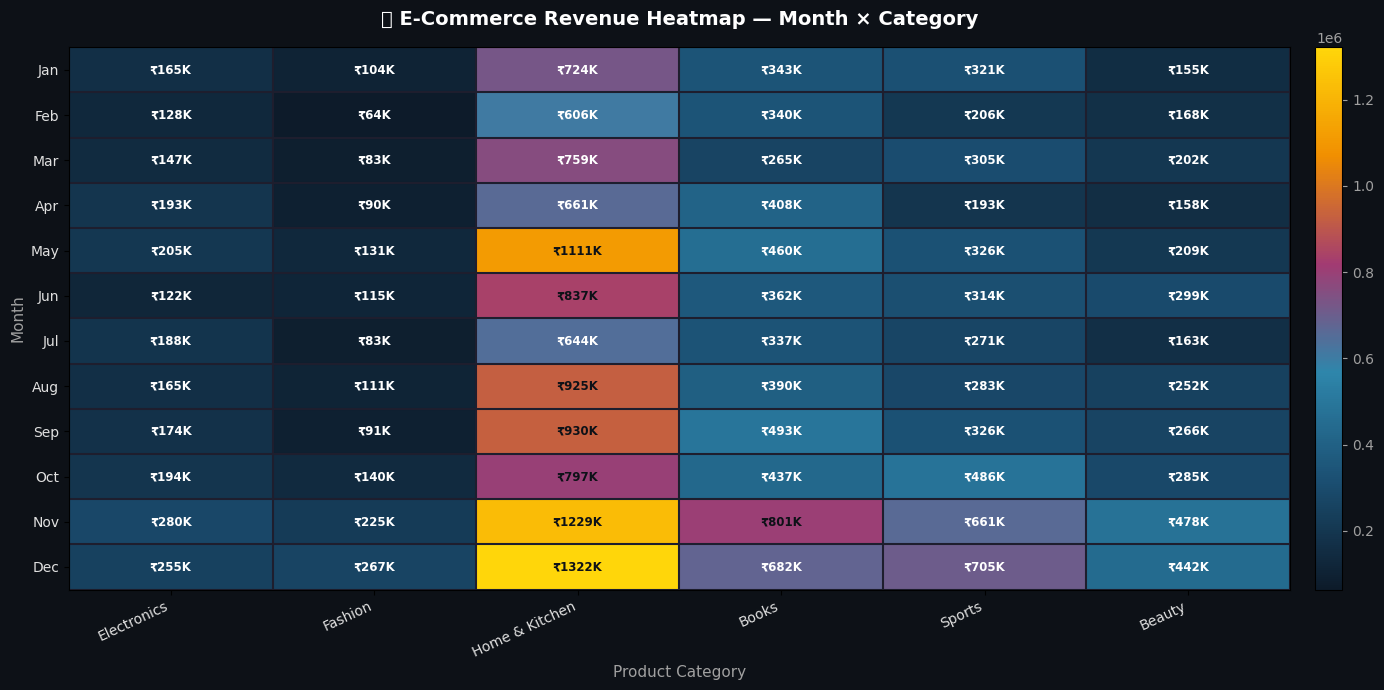

In [36]:
# ── CHART 1: Revenue Heatmap ─────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

colors_hm = ['#0D1B2A', '#1B4F72', '#2E86AB', '#A23B72', '#F18F01', '#FFD60A']
cmap = LinearSegmentedColormap.from_list('em', colors_hm, N=256)

data = pivot_rev.values
im = ax.imshow(data, cmap=cmap, aspect='auto')

ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, color='#E0E0E0', fontsize=10, rotation=25, ha='right')
ax.set_yticks(range(len(months)))
ax.set_yticklabels(months, color='#E0E0E0', fontsize=10)

for i in range(len(months)):
    for j in range(len(categories)):
        v  = data[i, j]
        tc = 'white' if v < data.max() * 0.6 else '#0D1117'
        ax.text(j, i, f'₹{v/1000:.0f}K', ha='center', va='center',
                color=tc, fontsize=8.5, fontweight='bold')

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02).ax.tick_params(colors='#A0A0A0')
ax.set_title('📊 E-Commerce Revenue Heatmap — Month × Category',
             color='white', fontsize=14, fontweight='bold', pad=16)
ax.set_xlabel('Product Category', color='#A0A0A0', fontsize=11)
ax.set_ylabel('Month', color='#A0A0A0', fontsize=11)
ax.set_xticks(np.arange(-.5, len(categories), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(months), 1), minor=True)
ax.grid(which='minor', color='#1E1E2E', linewidth=1.5)
ax.tick_params(which='minor', bottom=False, left=False)
plt.tight_layout()
plt.show()

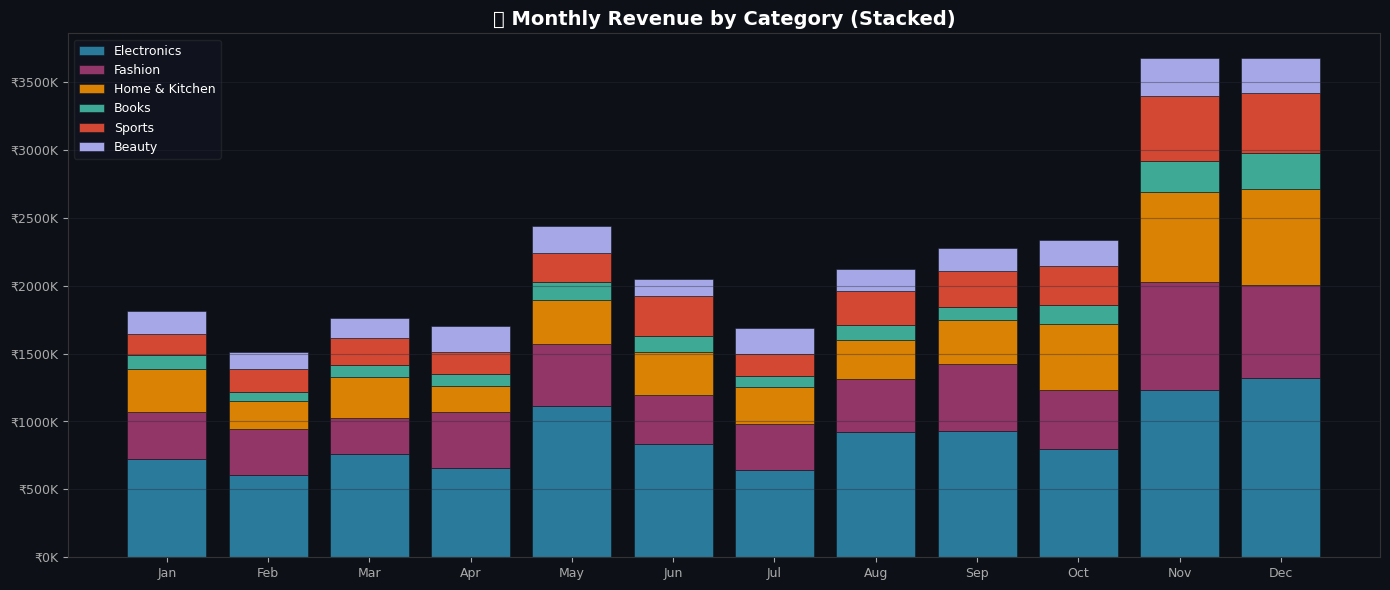

In [37]:
# ── CHART 2: Stacked Bar ─────────────────────────────────────
colors = ['#2E86AB','#A23B72','#F18F01','#44BBA4','#E94F37','#B8B8FF']
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

bottom = np.zeros(len(months))
for i, cat in enumerate(categories):
    vals = pivot_rev[cat].values
    ax.bar(months, vals, bottom=bottom, color=colors[i], label=cat,
           alpha=0.9, width=0.78, edgecolor='#0D1117', linewidth=0.4)
    bottom += vals

ax.tick_params(colors='#AAA', labelsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'₹{v/1000:.0f}K'))
ax.legend(fontsize=9, framealpha=0.3, facecolor='#1A1A2E', edgecolor='#444', labelcolor='white')
ax.set_title('📈 Monthly Revenue by Category (Stacked)', color='white', fontsize=14, fontweight='bold')
ax.grid(axis='y', color='#2A2A3A', alpha=0.4)
for spine in ax.spines.values(): spine.set_edgecolor('#333')
plt.tight_layout()
plt.show()

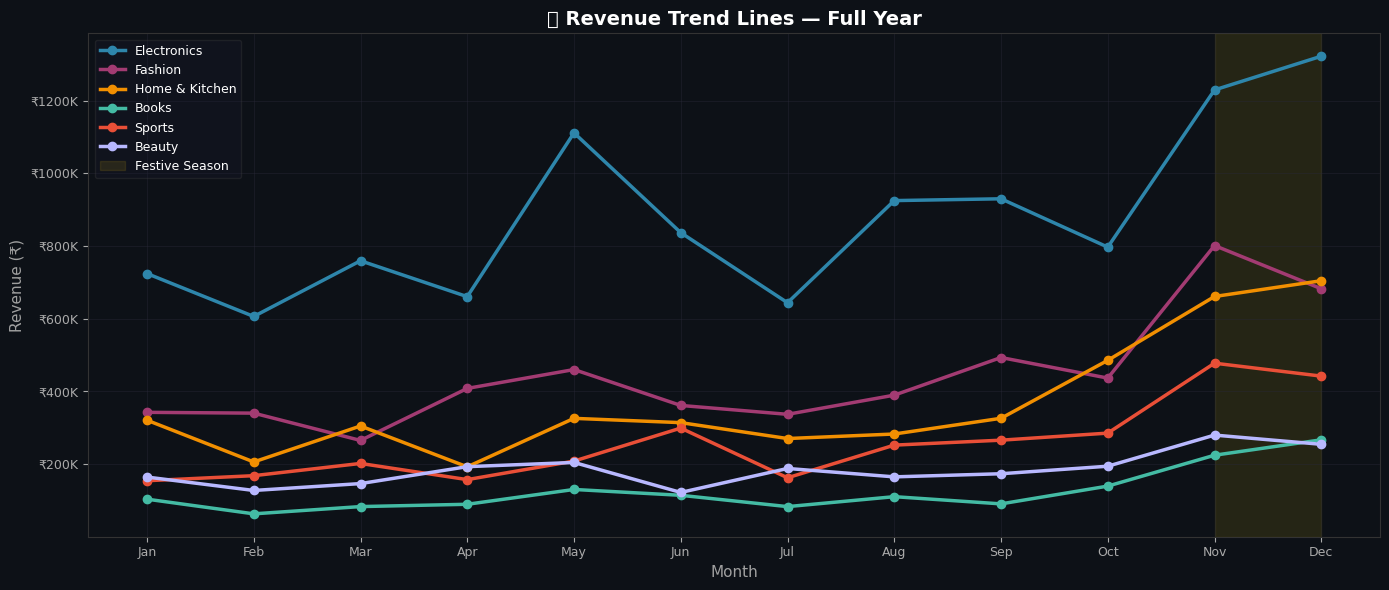

In [38]:
# ── CHART 3: Trend Lines ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0D1117')
ax.set_facecolor('#0D1117')

for i, cat in enumerate(categories):
    ax.plot(months, pivot_rev[cat].values, color=colors[i], marker='o',
            linewidth=2.5, markersize=6, label=cat)
ax.axvspan(10, 11, alpha=0.1, color='#FFD60A', label='Festive Season')

ax.tick_params(colors='#AAA', labelsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'₹{v/1000:.0f}K'))
ax.set_xlabel('Month', color='#A0A0A0', fontsize=11)
ax.set_ylabel('Revenue (₹)', color='#A0A0A0', fontsize=11)
ax.legend(fontsize=9, framealpha=0.3, facecolor='#1A1A2E', edgecolor='#444', labelcolor='white')
ax.set_title('📉 Revenue Trend Lines — Full Year', color='white', fontsize=14, fontweight='bold')
ax.grid(color='#2A2A3A', alpha=0.4)
for spine in ax.spines.values(): spine.set_edgecolor('#333')
plt.tight_layout()
plt.show()

---
## 15. Business Insights <a name='insights'></a>

In [39]:
total = ecom['Revenue'].sum()
print(f'Total Revenue: ₹{total:>15,.0f}')
print(f'Avg per Transaction: ₹{total/len(ecom):>10,.0f}')
print(f'Return Rate: {ecom["Returned"].mean()*100:.1f}%')
print()

print('🏆 Category Rankings:')
cat_totals = ecom.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
for i, (cat, rev) in enumerate(cat_totals.items(), 1):
    pct = rev / total * 100
    print(f'  {i}. {cat:<18s}  ₹{rev:>12,.0f}  ({pct:4.1f}%)')

Total Revenue: ₹     27,056,652
Avg per Transaction: ₹    10,823
Return Rate: 9.0%

🏆 Category Rankings:
  1. Electronics         ₹  10,544,565  (39.0%)
  2. Fashion             ₹   5,319,447  (19.7%)
  3. Home & Kitchen      ₹   4,396,645  (16.2%)
  4. Sports              ₹   3,077,392  (11.4%)
  5. Beauty              ₹   2,216,209  ( 8.2%)
  6. Books               ₹   1,502,394  ( 5.6%)


In [40]:
print('📅 Festive Season (Nov+Dec) vs rest of year:')
q4 = pivot_rev.loc[['Nov', 'Dec']].sum().sum()
rest = total - q4
print(f'  Nov + Dec: ₹{q4:>12,.0f}  ({q4/total*100:.1f}%)')
print(f'  Jan–Oct:   ₹{rest:>12,.0f}  ({rest/total*100:.1f}%)')
print()

print('🔍 Best month per category:')
for cat in categories:
    best = pivot_rev[cat].idxmax()
    val  = pivot_rev[cat].max()
    print(f'  {cat:<18s}: {best}  ₹{val:>10,.0f}')

📅 Festive Season (Nov+Dec) vs rest of year:
  Nov + Dec: ₹   7,346,686  (27.2%)
  Jan–Oct:   ₹  19,709,966  (72.8%)

🔍 Best month per category:
  Electronics       : Dec  ₹ 1,321,800
  Fashion           : Nov  ₹   801,191
  Home & Kitchen    : Dec  ₹   704,535
  Books             : Dec  ₹   267,056
  Sports            : Nov  ₹   477,764
  Beauty            : Nov  ₹   280,059


---
## 16. Cheatsheet & Interview Q&A <a name='cheatsheet'></a>

### MultiIndex Cheatsheet
```python
# Create
pd.MultiIndex.from_tuples([(a,b),(c,d)], names=['L1','L2'])
pd.MultiIndex.from_product([list1, list2], names=['L1','L2'])
pd.MultiIndex.from_arrays([arr1, arr2], names=['L1','L2'])

# Select
df.loc['outer']               # all rows where outer level = 'outer'
df.loc[('outer', 'inner')]    # specific row
df.xs('val', level='LevelName')  # cross-section (any level)
df.xs('val', level='LevelName', axis=1)  # on columns

# Reshape
df.stack()                    # innermost column level → innermost index level
df.unstack()                  # innermost index level → column level
df.unstack(level='City')      # specific level by name

# Reorder
df.swaplevel('A', 'B').sort_index()  # always sort after swaplevel!
df.sort_index(level='City')

# melt (wide → long)
pd.melt(df, id_vars=['a'], value_vars=['b','c'], var_name='X', value_name='Y')
```

### Pivot Table Cheatsheet
```python
# Basic
pd.pivot_table(df, values='V', index='R', columns='C', aggfunc='sum')

# With totals
pd.pivot_table(df, ..., margins=True, margins_name='Total')

# Multiple aggfuncs
pd.pivot_table(df, values='V', ..., aggfunc=['sum', 'mean'])

# Multiple index levels
pd.pivot_table(df, index=['Region', 'Month'], columns='Cat', ...)

# Multiple value columns
pd.pivot_table(df, values=['Revenue', 'Units'], ...)
```

### Interview Q&A

| Question | Answer |
|----------|--------|
| What is a MultiIndex? | Hierarchical index with multiple levels — allows nested row/column labelling |
| `stack()` vs `unstack()`? | `stack` moves columns → rows (wider to taller); `unstack` moves rows → columns (taller to wider) |
| Why sort_index after swaplevel? | MultiIndex slicing requires sorted index; unsorted raises UnsortedIndexError |
| `xs()` purpose? | Cross-section: select by value at any index level (not just outer level) |
| Wide vs Long format? | Wide = human readable; Long = machine/analysis friendly |
| `melt()` parameters? | `id_vars` = keep as-is; `value_vars` = melt these; `var_name` = col name; `value_name` = val col name |
| `pivot` vs `pivot_table`? | `pivot` requires unique index/col combos; `pivot_table` handles duplicates via aggfunc |
| What does `margins=True` add? | Grand total row and column ('All') — sum of all values |
| Can aggfunc be custom? | Yes: `aggfunc=lambda x: x.max() - x.min()` |
